<a href="https://colab.research.google.com/github/nandhnd/Tire-Texture-Extraction/blob/main/2318089_Nanda_FiturTekstur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. IMPORT LIBRARY

In [62]:
# Import library yang dibutuhkan
import cv2                      # OpenCV untuk pengolahan citra
import numpy as np              # Operasi numerik
import os                       # Akses folder & file
import pandas as pd             # Untuk tabel & simpan ke CSV/Excel
import matplotlib.pyplot as plt # Visualisasi gambar
from skimage.feature import graycomatrix, graycoprops  # GLCM fitur tekstur

#LOAD DATASET

In [63]:
# Menghubungkan Google Colab dengan Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
# Path folder dataset
folder_path = "/content/drive/MyDrive/KULIAH/semester 6/Computer Vision/ekstraksi fitur/ban"

#PREPROCESSING

In [65]:
def preprocess_image(img):
    # Resize gambar ke ukuran seragam
    img = cv2.resize(img, (256, 256))

    # Konversi ke grayscale (abu-abu)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Normalisasi pencahayaan (agar konsisten)
    gray = cv2.equalizeHist(gray)

    # Mengurangi noise (agar edge lebih bersih)
    gray = cv2.GaussianBlur(gray, (7,7), 0)

    return gray

#EKSTRAKSI FITUR

##FUNGSI EKTRAKSI FITUR

In [66]:
def extract_features(gray):
    # Edge Detection (Canny)
    edges = cv2.Canny(gray, 180, 300)

    kernel = np.ones((3,3), np.uint8)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Hitung jumlah pixel edge
    edge_count = np.sum(edges > 0)

    # Membuat matriks GLCM
    glcm = graycomatrix(gray,
                        distances=[1],   # jarak piksel
                        angles=[0],      # arah (horizontal)
                        levels=256,
                        symmetric=True,
                        normed=True)

    # Ekstraksi fitur tekstur dari GLCM
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    return edges, edge_count, contrast, energy, homogeneity

##MENJALANKAN FUNGSI PREPROCESSING DAN EKTRAKSI FITUR

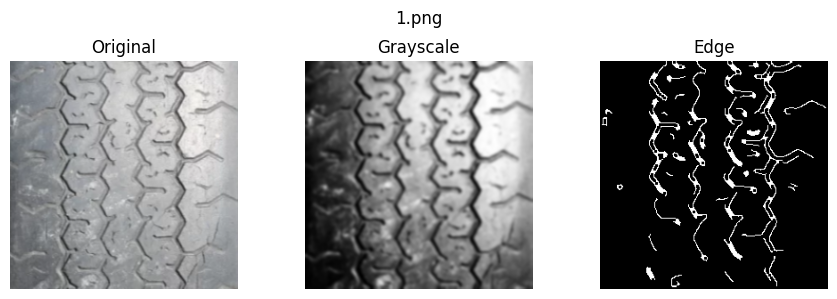

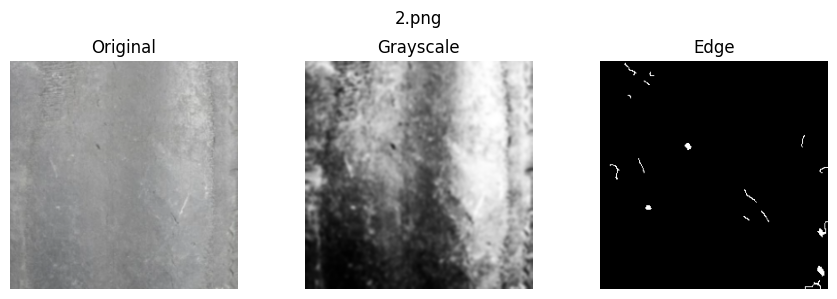

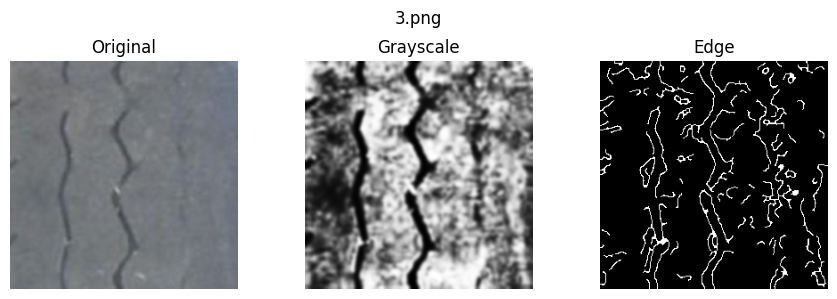

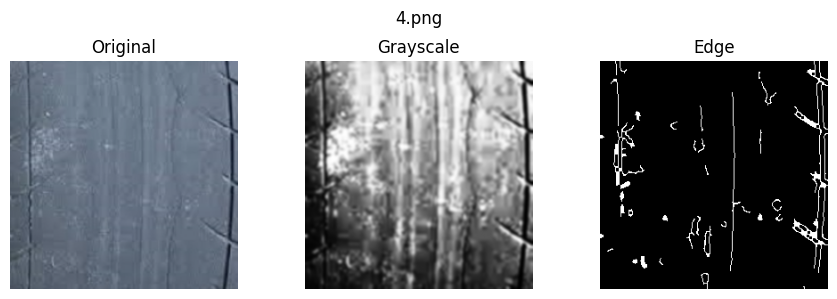

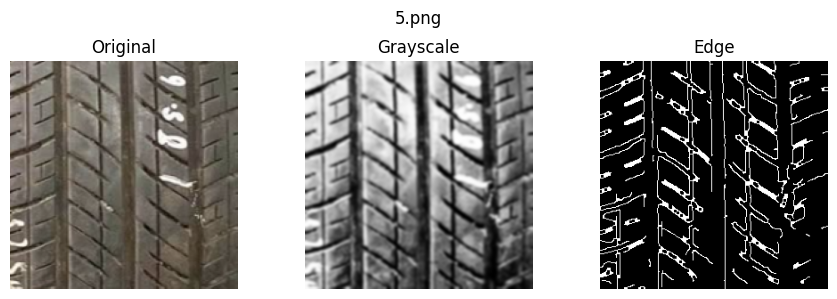

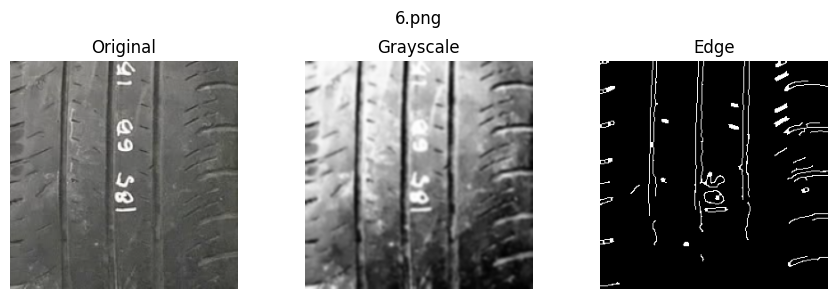

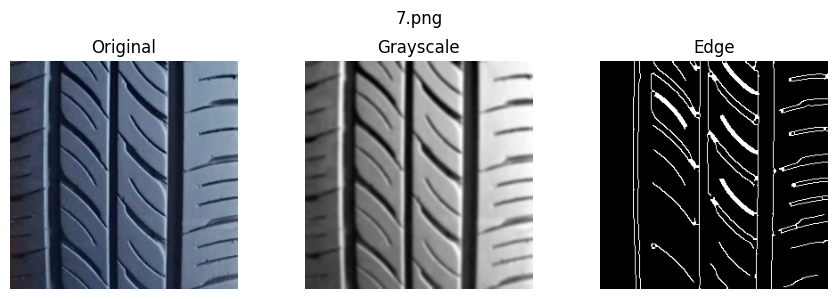

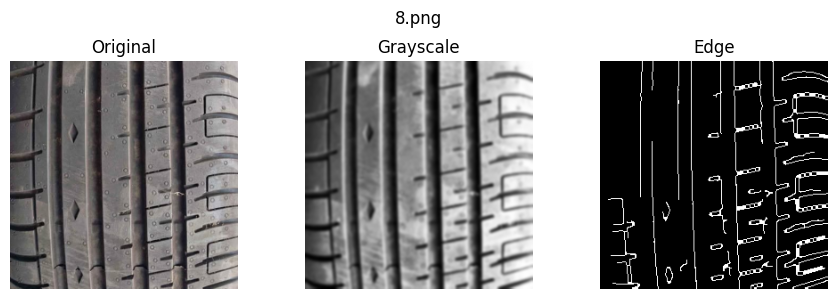

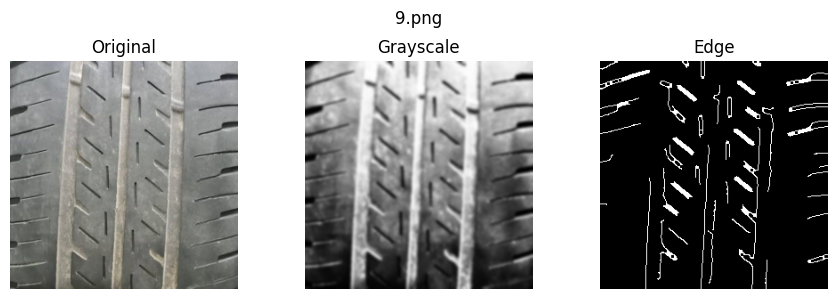

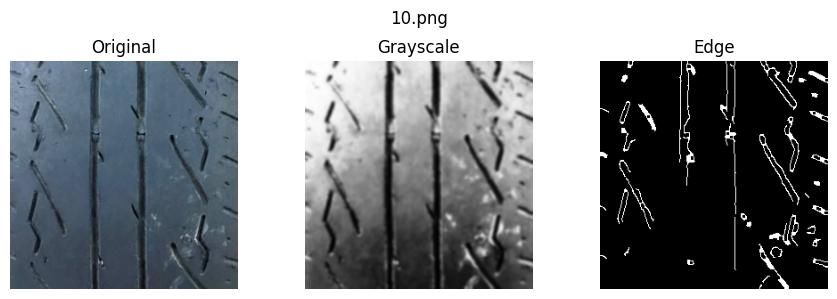

In [67]:
data = []  # list untuk menyimpan hasil

for filename in os.listdir(folder_path):
    # cek hanya file gambar
    if filename.lower().endswith(('.jpg', '.png', '.jpeg')):

        path = os.path.join(folder_path, filename)
        img = cv2.imread(path)

        # jika gagal baca gambar
        if img is None:
            print(f"Gagal baca: {filename}")
            continue

        # preprocessing
        gray = preprocess_image(img)

        # ekstraksi fitur
        edges, edge_count, contrast, energy, homogeneity = extract_features(gray)

        # simpan ke list
        data.append({
            "filename": filename,
            "edge_count": edge_count,
            "contrast": contrast,
            "energy": energy,
            "homogeneity": homogeneity
        })

        # Menampilkan gambar original, grayscale, dan edge
        plt.figure(figsize=(9,3))

        # 1. Original Image
        plt.subplot(1,3,1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis('off')

        # 2. Grayscale
        plt.subplot(1,3,2)
        plt.imshow(gray, cmap='gray')
        plt.title("Grayscale")
        plt.axis('off')

        # 3. Edge Detection
        plt.subplot(1,3,3)
        plt.imshow(edges, cmap='gray')
        plt.title("Edge")
        plt.axis('off')

        plt.suptitle(filename)
        plt.tight_layout()
        plt.show()

#MENAMPILKAN HASIL EKTRAKSI

In [68]:
# Mengubah list ke tabel (DataFrame)
df = pd.DataFrame(data)

In [69]:
# Menampilkan hasil ektraksi
print("\nPreview Data:")
print(df)


Preview Data:
  filename  edge_count    contrast    energy  homogeneity
0    1.png        4409   98.974770  0.015302     0.239658
1    2.png         412   40.038542  0.016553     0.245467
2    3.png        4499  179.465916  0.011268     0.129511
3    4.png        2712  147.718015  0.012613     0.165684
4    5.png        7447  198.682215  0.011348     0.143753
5    6.png        2783  123.940579  0.014594     0.225917
6    7.png        5207  194.054550  0.017317     0.290666
7    8.png        4852  177.202068  0.013219     0.188410
8    9.png        3876  103.770435  0.015372     0.248476
9   10.png        3401  129.318888  0.017748     0.301939


#SIMPAN FILE

In [70]:
# Path output file
csv_path = "/content/drive/MyDrive/KULIAH/semester 6/Computer Vision/ekstraksi fitur/hasil_fitur_ban.csv"

# Simpan ke CSV
df.to_csv(csv_path, index=False)

print("📁 CSV:", csv_path)

📁 CSV: /content/drive/MyDrive/KULIAH/semester 6/Computer Vision/ekstraksi fitur/hasil_fitur_ban.csv
